In [195]:
import numpy as np
import pandas as pd 
import cv2

In [196]:
dataset_path = "/Users/taktakro/Desktop/course files/Houses Dataset/HousesInfo.txt"

In [197]:
#Table

data_tab = pd.read_csv(dataset_path, sep=" ", names = ['Bedrooms', 'Bathrooms', 'Area', 'ZipCode', 'Price'])

In [198]:
data_tab.isna().sum()

Bedrooms     0
Bathrooms    0
Area         0
ZipCode      0
Price        0
dtype: int64

In [199]:
# convert to one hot will export 49 columns
data_tab.ZipCode.unique().shape

(49,)

In [200]:
zipCode = np.unique(data_tab.ZipCode, return_counts=True)
zipCode

(array([36372, 60002, 60016, 60046, 62025, 62034, 62088, 62214, 62234,
        62249, 81418, 81521, 81524, 85255, 85262, 85266, 85331, 85377,
        90038, 90211, 90265, 90803, 91752, 91901, 91915, 92021, 92040,
        92253, 92276, 92543, 92677, 92692, 92802, 92880, 93105, 93111,
        93314, 93446, 93510, 93720, 93924, 94501, 94531, 94565, 94568,
        95008, 95220, 96019, 98021]),
 array([  1,   3,   2,   1,   2,   1,   1,   4,   7,   1,   2,   1,  11,
         12,   9,  11,   1,   3,   1,   1,   1,   1,   3,  32,   1,  11,
          1,   2, 100,   1,  26,   2,   9,  49,   1,  11,   1,  54,  60,
          1,   1,  41,  22,   1,   1,   1,  10,  12,   4]))

In [201]:

zip_count = np.unique(data_tab.ZipCode, return_counts=True)[1]
zip_count

array([  1,   3,   2,   1,   2,   1,   1,   4,   7,   1,   2,   1,  11,
        12,   9,  11,   1,   3,   1,   1,   1,   1,   3,  32,   1,  11,
         1,   2, 100,   1,  26,   2,   9,  49,   1,  11,   1,  54,  60,
         1,   1,  41,  22,   1,   1,   1,  10,  12,   4])

In [202]:
zip_count[zip_count >= 9].shape

(17,)

In [203]:
for i,j in zip(zipCode[0], zipCode[1]):
   if j < 9:
      data_tab.loc[data_tab.ZipCode == i,'ZipCode'] = 0

In [204]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [205]:
ohe_encoder = OneHotEncoder()
zipCode_encode = ohe_encoder.fit_transform(data_tab.ZipCode.values.reshape(-1, 1)).toarray()

In [231]:
zipCode_encode.shape

(535, 18)

In [207]:
len(data_tab)

535

In [208]:
scaler = StandardScaler()
data_tab_scaled = scaler.fit_transform(data_tab[['Bedrooms', 'Bathrooms', 'Area']])

In [209]:
data_tab_scaled

array([[ 0.53663907,  1.34290707,  1.37982571],
       [ 0.53663907,  0.33701938,  0.79948155],
       [-0.3255288 ,  1.34290707,  1.27356551],
       ...,
       [-0.3255288 , -0.66886831, -0.28682461],
       [ 0.53663907,  0.33701938, -0.04324355],
       [ 1.39880694,  0.33701938,  1.16975747]])

In [210]:
max_price = data_tab.Price.max()
price = data_tab.Price / max_price

In [211]:
data_tab = np.concatenate([data_tab_scaled, zipCode_encode], axis = 1)

In [232]:
data_tab.shape, data_tab_scaled.shape, zipCode_encode.shape

((535, 21), (535, 3), (535, 18))

Image Data

In [213]:
dataset_image_path = "/Users/taktakro/Desktop/course files/Houses Dataset"

In [214]:
from glob import glob

In [215]:
img_path = glob(dataset_image_path+"/1_*.jpg")
img_path.sort()
img_path

['/Users/taktakro/Desktop/course files/Houses Dataset/1_bathroom.jpg',
 '/Users/taktakro/Desktop/course files/Houses Dataset/1_bedroom.jpg',
 '/Users/taktakro/Desktop/course files/Houses Dataset/1_frontal.jpg',
 '/Users/taktakro/Desktop/course files/Houses Dataset/1_kitchen.jpg']

set 4 images in a image  --->  
4 * (64 * 64 * 3) >>> 128 * 128 * 3    OR 
4 * 64 * 64 * 3 >>> 64 * 64 * 12

In [216]:
# Solution 1

data_img = []

for i in range(1, len(data_tab) + 1 ):
   img_path = glob(dataset_image_path + f"/{i}_*.jpg")
   img_path.sort()
   img_list = []
   for path in img_path:
      img = cv2.imread(path)
      img = cv2.resize(img,(64,64))
      img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
      img_list.append(img)

   img_combo = np.zeros([64, 64, 12])

   img_combo[:,:,0:3] = img_list[0]
   img_combo[:,:,3:6] = img_list[1]
   img_combo[:,:,6:9] = img_list[2]
   img_combo[:,:,9:12] = img_list[3]

   data_img.append(img_combo)
   
   
data_img = np.array(data_img) / 255


In [217]:
# Solution 2

# data_img = []

# for i in range(1, len(data_tab) + 1 ):
#    img_path = glob(dataset_image_path + f"/{i}_*.jpg")
#    img_path.sort()
#    img_list = []
#    for path in img_path:
#       img = cv2.imread(path)
#       img = cv2.resize(img,(64,64))
#       img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#       img_list.append(img)

#    img_combo = np.zeros([128, 128, 3])

#    img_combo[0:64,0:64] = img_list[0]
#    img_combo[0:64,64:128] = img_list[1]
#    img_combo[64:128,0:64] = img_list[2]
#    img_combo[64:128,64:128] = img_list[3]

#    data_img.append(img_combo)
   
   
# data_img = np.array(data_img) / 255


In [218]:
data_img[0].shape

(64, 64, 12)

In [219]:
x_tab_train = data_tab[:435]
x_tab_test = data_tab[435:]

x_img_train = data_img[:435]
x_img_test = data_img[435:]

y_train = price[:435]
y_test = price[435:]

In [220]:
import matplotlib.pyplot as plt

In [228]:
print(data_img[0].shape)

print("Min:", np.min(data_img[0]))
print("Max:", np.max(data_img[0]))
print(data_img[0].dtype)

(64, 64, 12)
Min: 0.0
Max: 1.0
float64


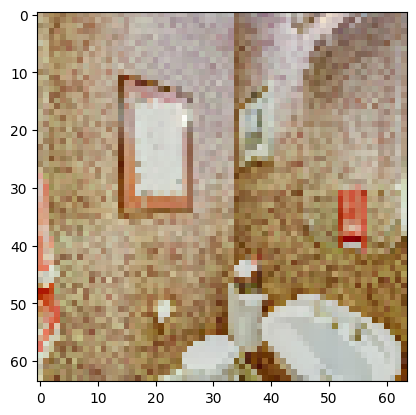

In [230]:
plt.imshow(data_img[0][:, :, :3])
plt.show()

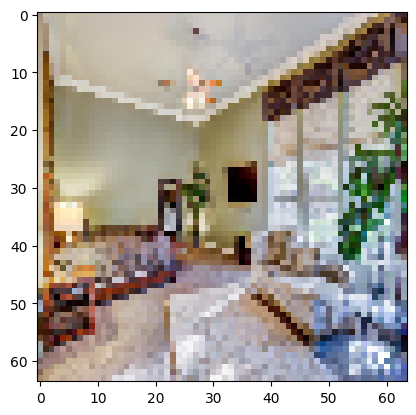

In [229]:
plt.imshow(data_img[0][:, :, 3:6])
plt.show()

In [233]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Conv2D, Dropout, Input, Concatenate, Flatten, MaxPool2D
from tensorflow.keras.models import Model

In [242]:
input_layer_ch1 = Input(shape =(21,))

dense1 = Dense(64, activation='relu')(input_layer_ch1)
dense_layer1_ch1 = Dense(units=128, activation='relu')(dense1)
dp = Dropout(.4)(dense_layer1_ch1)
dense_layer2_ch1 = Dense(units=128, activation='relu')(dp)

# solution 1
input_layer_ch2 = Input(shape = (64,64,12))

# solution 2
# input_layer_ch2 = Input(shape = (128,128,3))
conv_layer1_ch2 = Conv2D(16,(3,3), activation='relu')(input_layer_ch2)
dp = Dropout(.4)(conv_layer1_ch2)
maxpool1_ch2 = MaxPool2D()(dp)
conv_layer2_ch2 = Conv2D(32,(3,3), activation='relu')(maxpool1_ch2)
dp = Dropout(.4)(conv_layer2_ch2)
maxpool2_ch2 = MaxPool2D()(dp)
flatten = Flatten()(maxpool2_ch2)
dense_img = Dense(32, activation='relu')(flatten)

concat = Concatenate()([dense_layer2_ch1, dense_img])

output_layer = Dense(1, activation='linear')(concat)

In [243]:
model = Model(inputs=[input_layer_ch1, input_layer_ch2], outputs=[output_layer] )

In [244]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 62, 62,    │      1,744 │ input_layer_19[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 62, 62,    │          0 │ conv2d_18[0][0]   │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 31, 31,    │          0 │ dropout_22[0][0]  │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_18      │ (None, 21)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 29, 29,    │      4,640 │ max_pooling2d_18… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 64)        │      1,408 │ input_layer_18[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_23          │ (None, 29, 29,    │          0 │ conv2d_19[0][0]   │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 128)       │      8,320 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 14, 14,    │          0 │ dropout_23[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 128)       │          0 │ dense_27[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 6272)      │          0 │ max_pooling2d_19… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 128)       │     16,512 │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 32)        │    200,736 │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 160)       │          0 │ dense_28[0][0],   │
│ (Concatenate)       │                   │            │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 1)         │        161 │ concatenate_9[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 233,521 (912.19 KB)

 Trainable params: 233,521 (912.19 KB)

 Non-trainable params: 0 (0.00 B)

In [249]:
from tensorflow.keras.utils import plot_model

In [250]:
plot_model(model)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [251]:
# complile model
opt = tf.optimizers.Adam(learning_rate=.001)
loss = tf.losses.CategoricalCrossentropy()

model.compile(optimizer=opt, loss=loss)

In [ ]:
model.fit([x_tab_train, x_img_train], y_train, epochs=100, validation_data=[[x_tab_test, x_img_test], y_test], verbose=2)